# Phase 2: Federated Agent Partitioning & Isolation Analysis (Self-Contained)
**Context**: This notebook demonstrates the Phase 2 isolated simulation. Here, the global SCM dataset is sliced, and two independent RL agents (Agent 1 and Agent 2) attempt to discover their local causal graphs. This notebook is fully self-contained and runs on Google Colab.


In [1]:
!pip install gymnasium networkx matplotlib torch numpy


In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)


## Module 1: Data Generation and Partitioning

In [3]:
class LinearGaussianSCM:
    def __init__(self, num_vars=10, random_seed=42):
        self.num_vars = num_vars
        self.rng = np.random.default_rng(random_seed)
        self.adjacency_matrix = np.zeros((self.num_vars, self.num_vars), dtype=int)
        edges = [(0, 1), (1, 2), (2, 3), (3, 4), (5, 4), (5, 6), (6, 7), (7, 8), (8, 9)]
        for u, v in edges:
            self.adjacency_matrix[u, v] = 1
        G = nx.DiGraph(self.adjacency_matrix)
        if not nx.is_directed_acyclic_graph(G):
            raise ValueError("Not a DAG!")
        self.weight_matrix = np.zeros_like(self.adjacency_matrix, dtype=float)
        for u, v in edges:
            sign = self.rng.choice([-1, 1])
            weight = sign * self.rng.uniform(0.5, 1.5)
            self.weight_matrix[u, v] = weight
        self.topological_order = list(nx.topological_sort(G))

    def generate_data(self, num_samples, noise_std=1.0):
        data = np.zeros((num_samples, self.num_vars))
        for node in self.topological_order:
            noise = self.rng.normal(0, noise_std, size=num_samples)
            parents = np.where(self.adjacency_matrix[:, node] == 1)[0]
            if len(parents) == 0:
                data[:, node] = noise
            else:
                parent_values = data[:, parents]
                weights = self.weight_matrix[parents, node]
                data[:, node] = parent_values @ weights + noise
        return data

def partition_data(data: np.ndarray):
    centralized_data = data.copy()
    agent1_data = data[:, 0:6].copy()
    agent2_data = data[:, 4:10].copy()
    return centralized_data, agent1_data, agent2_data


## Module 2: BIC Scoring and Metrics

In [4]:
class GaussianBIC:
    def __init__(self, data: np.ndarray):
        self.data = data
        self.num_samples, self.num_vars = data.shape

    def compute_node_bic(self, node: int, parents: list) -> float:
        y = self.data[:, node]
        if len(parents) == 0:
            rss = np.sum((y - np.mean(y)) ** 2)
            k = 0
        else:
            X = self.data[:, parents]
            X = np.hstack((np.ones((self.num_samples, 1)), X))
            beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
            residuals = y - X @ beta
            rss = np.sum(residuals ** 2)
            k = len(parents)
        var_hat = max(rss / self.num_samples, 1e-8)
        log_likelihood = -0.5 * self.num_samples * (np.log(2 * np.pi * var_hat) + 1)
        return -2 * log_likelihood + k * np.log(self.num_samples)

    def compute_graph_bic(self, adjacency_matrix: np.ndarray) -> float:
        total_bic = 0.0
        for v in range(self.num_vars):
            parents = np.where(adjacency_matrix[:, v] == 1)[0].tolist()
            total_bic += self.compute_node_bic(v, parents)
        return total_bic

def compute_shd(pred_dag: np.ndarray, true_dag: np.ndarray) -> int:
    shd = 0
    num_vars = pred_dag.shape[0]
    for i in range(num_vars):
        for j in range(i + 1, num_vars):
            pred_edge = max(pred_dag[i, j], pred_dag[j, i])
            true_edge = max(true_dag[i, j], true_dag[j, i])
            if pred_edge == 1 and true_edge == 0: shd += 1
            elif pred_edge == 0 and true_edge == 1: shd += 1
            elif pred_edge == 1 and true_edge == 1:
                if pred_dag[i, j] != true_dag[i, j]: shd += 1
    return shd

def compute_overlap_metrics(pred_dag, true_dag, v5_idx, v6_idx):
    tp, fp, fn = 0, 0, 0
    edges_to_check = [(v5_idx, v6_idx), (v6_idx, v5_idx)]
    for u, v in edges_to_check:
        true_edge, pred_edge = true_dag[u, v], pred_dag[u, v]
        if true_edge == 1 and pred_edge == 1: tp += 1
        elif true_edge == 0 and pred_edge == 1: fp += 1
        elif true_edge == 1 and pred_edge == 0: fn += 1
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fdr = fp / (tp + fp) if (tp + fp) > 0 else 0.0
    return tpr, fdr


## Module 3: RL Environment

In [5]:
class CausalDiscoveryEnv(gym.Env):
    ACTION_ADD, ACTION_REMOVE, ACTION_REVERSE = 0, 1, 2
    
    def __init__(self, data, max_steps=100, lambda_sparse=0.0, step_cost=0.1, invalid_penalty=10.0, max_edges=None):
        super().__init__()
        self.data = data
        self.num_samples, self.num_vars = data.shape
        self.max_steps = max_steps
        self.lambda_sparse = lambda_sparse
        self.step_cost = step_cost
        self.invalid_penalty = invalid_penalty
        self.max_edges = max_edges if max_edges else (self.num_vars * (self.num_vars - 1)) // 2
        
        self.bic_calculator = GaussianBIC(data)
        self.observation_space = spaces.MultiBinary(self.num_vars * self.num_vars)
        self.num_possible_edges = self.num_vars * (self.num_vars - 1)
        self.action_space = spaces.Discrete(3 * self.num_possible_edges)
        
        self.action_mapping = []
        for op in [self.ACTION_ADD, self.ACTION_REMOVE, self.ACTION_REVERSE]:
            for i in range(self.num_vars):
                for j in range(self.num_vars):
                    if i != j: self.action_mapping.append((op, i, j))
                        
        self.current_step = 0
        self.adjacency_matrix = np.zeros((self.num_vars, self.num_vars), dtype=int)
        self.current_bic = 0.0
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.adjacency_matrix = np.zeros((self.num_vars, self.num_vars), dtype=int)
        self.current_bic = self.bic_calculator.compute_graph_bic(self.adjacency_matrix)
        return self.adjacency_matrix.flatten(), {'action_mask': self.get_action_mask(), 'bic': self.current_bic, 'edges': 0}

    def _simulate_action(self, op, i, j):
        new_matrix = self.adjacency_matrix.copy()
        if op == self.ACTION_ADD: new_matrix[i, j] = 1
        elif op == self.ACTION_REMOVE: new_matrix[i, j] = 0
        elif op == self.ACTION_REVERSE:
            new_matrix[i, j] = 0
            new_matrix[j, i] = 1
        return new_matrix

    def get_action_mask(self):
        mask = np.zeros(self.action_space.n, dtype=np.int8)
        current_edges = np.sum(self.adjacency_matrix)
        for action_idx, (op, i, j) in enumerate(self.action_mapping):
            if op == self.ACTION_ADD:
                if self.adjacency_matrix[i, j] == 1 or self.adjacency_matrix[j, i] == 1 or current_edges >= self.max_edges: continue
            elif op == self.ACTION_REMOVE and self.adjacency_matrix[i, j] == 0: continue
            elif op == self.ACTION_REVERSE and self.adjacency_matrix[i, j] == 0: continue
            if op in [self.ACTION_ADD, self.ACTION_REVERSE]:
                new_matrix = self._simulate_action(op, i, j)
                try:
                    if not nx.is_directed_acyclic_graph(nx.DiGraph(new_matrix)): continue
                except: continue
            mask[action_idx] = 1
        return mask
        
    def step(self, action: int):
        self.current_step += 1
        op, i, j = self.action_mapping[action]
        mask = self.get_action_mask()
        
        if mask[action] == 0:
            return self.adjacency_matrix.flatten(), -self.invalid_penalty, False, self.current_step >= self.max_steps, {'action_mask': mask, 'bic': self.current_bic, 'edges': np.sum(self.adjacency_matrix)}
            
        self.adjacency_matrix = self._simulate_action(op, i, j)
        new_bic = self.bic_calculator.compute_graph_bic(self.adjacency_matrix)
        delta_bic = (self.current_bic - new_bic) / self.num_vars
        l0_norm = np.sum(self.adjacency_matrix)
        reward = delta_bic - (self.lambda_sparse * l0_norm) - self.step_cost
        self.current_bic = new_bic
        
        return self.adjacency_matrix.flatten(), float(reward), False, self.current_step >= self.max_steps, {'action_mask': self.get_action_mask(), 'bic': self.current_bic, 'edges': l0_norm}


## Module 4: RL Agent Architecture

In [6]:
class QNetwork(nn.Module):
    def __init__(self, obs_size: int, action_size: int):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(obs_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, action_size)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)

class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)
    def push(self, state, action, reward, next_state, next_mask, done):
        self.buffer.append((state, action, reward, next_state, next_mask, done))
    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, next_masks, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards, dtype=np.float32), 
                np.array(next_states), np.array(next_masks), np.array(dones, dtype=np.float32))
    def __len__(self): return len(self.buffer)

class DDQNAgent:
    def __init__(self, obs_size, action_size, lr=1e-3, gamma=0.99, buffer_capacity=10000):
        self.obs_size = obs_size
        self.action_size = action_size
        self.gamma = gamma
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.q_network = QNetwork(obs_size, action_size).to(self.device)
        self.target_network = QNetwork(obs_size, action_size).to(self.device)
        self.update_target_network()
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.replay_buffer = ReplayBuffer(buffer_capacity)
        
    def update_target_network(self):
        self.target_network.load_state_dict(self.q_network.state_dict())
        
    def select_action(self, state, mask, epsilon):
        valid_actions = np.where(mask == 1)[0]
        if len(valid_actions) == 0: return 0
        if random.random() < epsilon: return random.choice(valid_actions)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            q_values = self.q_network(state_t).cpu().numpy()[0]
        masked_q_values = np.where(mask == 1, q_values, -np.inf)
        if np.all(masked_q_values == -np.inf): return random.choice(valid_actions)
        return int(np.argmax(masked_q_values))
        
    def update(self, batch_size):
        if len(self.replay_buffer) < batch_size: return 0.0
        states, actions, rewards, next_states, next_masks, dones = self.replay_buffer.sample(batch_size)
        states, actions, rewards = torch.FloatTensor(states).to(self.device), torch.LongTensor(actions).unsqueeze(1).to(self.device), torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states, next_masks, dones = torch.FloatTensor(next_states).to(self.device), torch.FloatTensor(next_masks).to(self.device), torch.FloatTensor(dones).unsqueeze(1).to(self.device)
        with torch.no_grad():
            next_q_online = self.q_network(next_states).masked_fill(next_masks == 0, -1e9)
            next_actions = next_q_online.argmax(1, keepdim=True)
            next_q_target = self.target_network(next_states).gather(1, next_actions)
            target_q = rewards + self.gamma * (1 - dones) * next_q_target
        current_q = self.q_network(states).gather(1, actions)
        loss = nn.MSELoss()(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
        self.optimizer.step()
        return loss.item()


## Module 5: Execute and Visualize Training

In [7]:
# Setup Data
scm = LinearGaussianSCM(num_vars=10, random_seed=42)
data = scm.generate_data(num_samples=2000)
centralized, agent1_data, agent2_data = partition_data(data)
true_dag = scm.adjacency_matrix
agent1_true_dag = true_dag[0:6, 0:6]
agent2_true_dag = true_dag[4:10, 4:10]

def train_agent_loop(data, true_subgraph, overlap_indices, lr=1e-3, batch_size=32, episodes=30):
    env = CausalDiscoveryEnv(data, max_steps=40, step_cost=0.01)
    agent = DDQNAgent(obs_size=36, action_size=env.action_space.n, lr=lr)
    epsilon, epsilon_end, epsilon_decay = 1.0, 0.05, 0.95
    best_bic = float('inf')
    champion_dag = None
    metrics = {'shd': [], 'reward': [], 'tpr': [], 'fdr': []}
    v5_idx, v6_idx = overlap_indices
    for episode in range(episodes):
        obs, info = env.reset()
        mask = info['action_mask']
        done, ep_reward = False, 0.0
        while not done:
            action = agent.select_action(obs, mask, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_mask = info['action_mask']
            done = terminated or truncated
            agent.replay_buffer.push(obs, action, reward, next_obs, next_mask, done)
            agent.update(batch_size=batch_size)
            ep_reward += reward
            obs, mask = next_obs, next_mask
            if info['bic'] < best_bic:
                best_bic = info['bic']
                champion_dag = env.adjacency_matrix.copy()
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        if (episode + 1) % 5 == 0: agent.update_target_network()
        current_shd = compute_shd(champion_dag, true_subgraph) if champion_dag is not None else 15
        tpr, fdr = compute_overlap_metrics(champion_dag, true_subgraph, v5_idx, v6_idx) if champion_dag is not None else (0,0)
        metrics['shd'].append(current_shd)
        metrics['reward'].append(ep_reward)
        metrics['tpr'].append(tpr)
        metrics['fdr'].append(fdr)
    return champion_dag, metrics

print("Training Agent 1 (Observed V1-V6)...")
a1_dag, a1_metrics = train_agent_loop(agent1_data, agent1_true_dag, (4,5), lr=1e-3, batch_size=32, episodes=40)

print("Training Agent 2 (Observed V5-V10)...")
a2_dag, a2_metrics = train_agent_loop(agent2_data, agent2_true_dag, (0,1), lr=1e-3, batch_size=32, episodes=40)


Training Agent 1 (Observed V1-V6)...
Training Agent 2 (Observed V5-V10)...


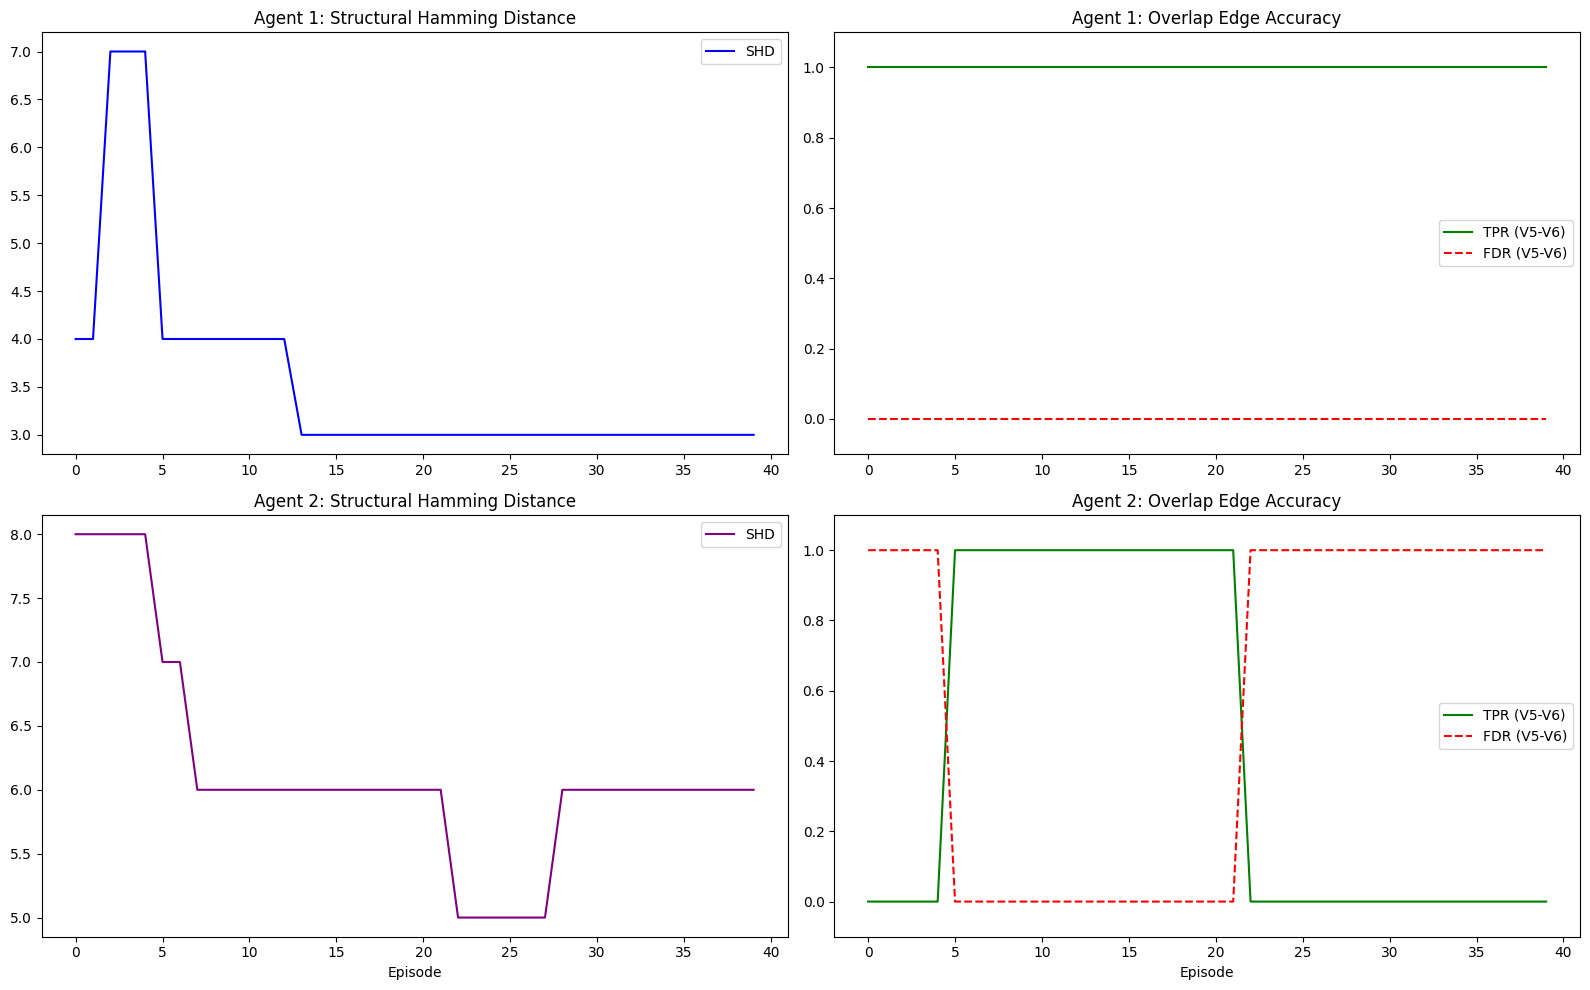

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs[0,0].plot(a1_metrics['shd'], color='blue', label='SHD')
axs[0,0].set_title("Agent 1: Structural Hamming Distance")
axs[0,0].legend()
axs[0,1].plot(a1_metrics['tpr'], color='green', label='TPR (V5-V6)')
axs[0,1].plot(a1_metrics['fdr'], color='red', linestyle='--', label='FDR (V5-V6)')
axs[0,1].set_title("Agent 1: Overlap Edge Accuracy")
axs[0,1].set_ylim([-0.1, 1.1])
axs[0,1].legend()
axs[1,0].plot(a2_metrics['shd'], color='purple', label='SHD')
axs[1,0].set_title("Agent 2: Structural Hamming Distance")
axs[1,0].set_xlabel("Episode")
axs[1,0].legend()
axs[1,1].plot(a2_metrics['tpr'], color='green', label='TPR (V5-V6)')
axs[1,1].plot(a2_metrics['fdr'], color='red', linestyle='--', label='FDR (V5-V6)')
axs[1,1].set_title("Agent 2: Overlap Edge Accuracy")
axs[1,1].set_ylim([-0.1, 1.1])
axs[1,1].set_xlabel("Episode")
axs[1,1].legend()
plt.tight_layout()
plt.show()


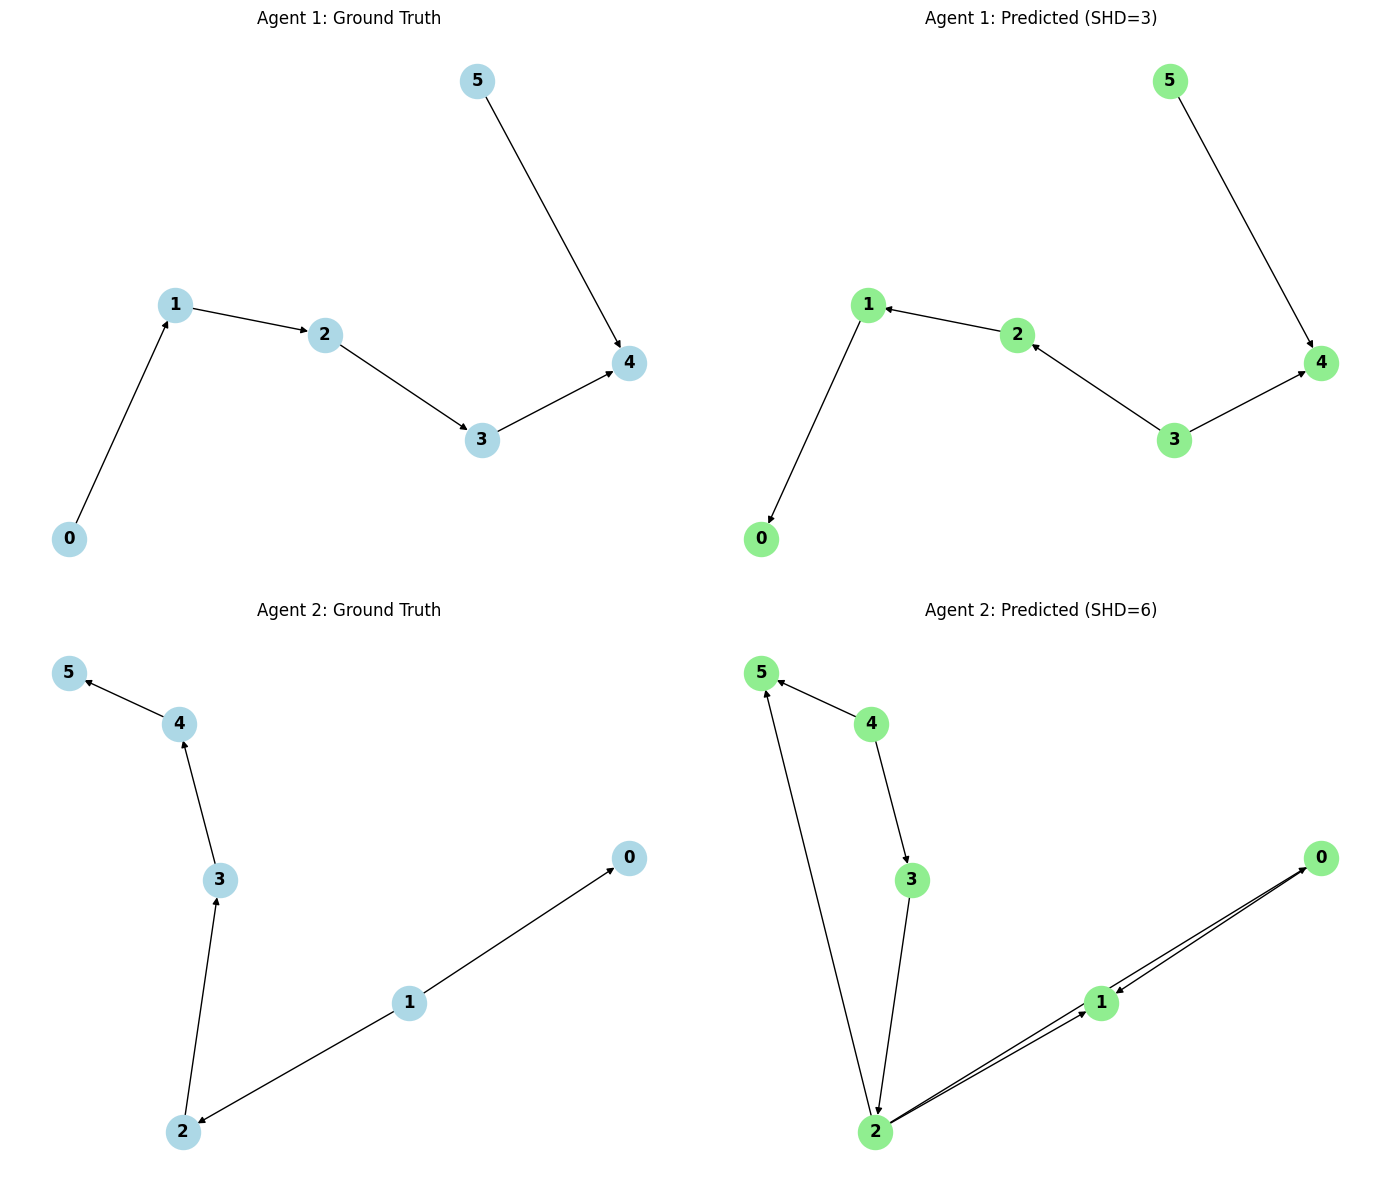

In [9]:
def draw_comparisons(true_dag, pred_dag, title_prefix, ax_true, ax_pred):
    G_true = nx.DiGraph(true_dag)
    G_pred = nx.DiGraph(pred_dag)
    pos = nx.spring_layout(G_true, seed=42)
    nx.draw(G_true, pos, ax=ax_true, with_labels=True, node_color='lightblue', node_size=600, font_weight='bold')
    ax_true.set_title(f"{title_prefix}: Ground Truth")
    nx.draw(G_pred, pos, ax=ax_pred, with_labels=True, node_color='lightgreen', node_size=600, font_weight='bold')
    final_shd = compute_shd(pred_dag, true_dag)
    ax_pred.set_title(f"{title_prefix}: Predicted (SHD={final_shd})")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
draw_comparisons(agent1_true_dag, a1_dag, "Agent 1", axes[0,0], axes[0,1])
draw_comparisons(agent2_true_dag, a2_dag, "Agent 2", axes[1,0], axes[1,1])
plt.tight_layout()
plt.show()
